In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %% [1] Install Requirements
!pip install transformers torch pandas scikit-learn seaborn matplotlib

# %% [2] Imports
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer

Loaded 2367 test samples
Filtered to 2367 supported dialect samples
Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Successfully loaded dialect model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded model for Egypt dialect


...

✅ Loaded model for Sudan dialect


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

✅ Loaded model for Lebanon dialect


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded model for Tunisia dialect

Starting evaluation...

DIALECT IDENTIFICATION PERFORMANCE
              precision    recall  f1-score   support

       Egypt       0.89      0.84      0.86       110
       Sudan       0.94      0.97      0.95       920
     Lebanon       0.97      0.96      0.97       691
     Tunisia       0.97      0.94      0.95       646

    accuracy                           0.95      2367
   macro avg       0.94      0.93      0.93      2367
weighted avg       0.95      0.95      0.95      2367



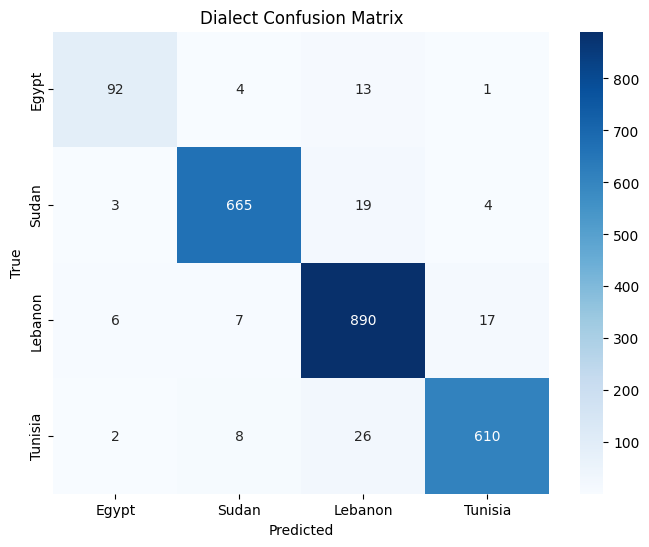


HATE SPEECH CLASSIFICATION PERFORMANCE (Stage 2)
Evaluated on 2257 samples (correct dialect only)
              precision    recall  f1-score   support

     abusive       0.67      0.72      0.69       382
        hate       0.70      0.80      0.75       560
      normal       0.90      0.83      0.87      1315

    accuracy                           0.80      2257
   macro avg       0.76      0.78      0.77      2257
weighted avg       0.81      0.80      0.81      2257



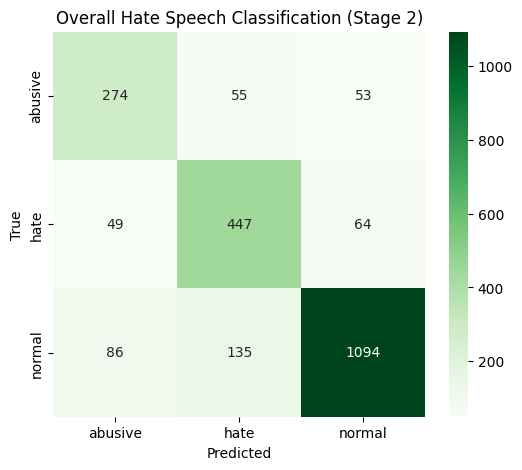


END-TO-END SYSTEM PERFORMANCE (Stage 1 + 2 combined)
Evaluated on 2367 samples (all, regardless of dialect accuracy)
              precision    recall  f1-score   support

     abusive       0.66      0.69      0.67       414
        hate       0.68      0.78      0.73       580
      normal       0.90      0.83      0.86      1373

    accuracy                           0.79      2367
   macro avg       0.75      0.77      0.76      2367
weighted avg       0.80      0.79      0.80      2367



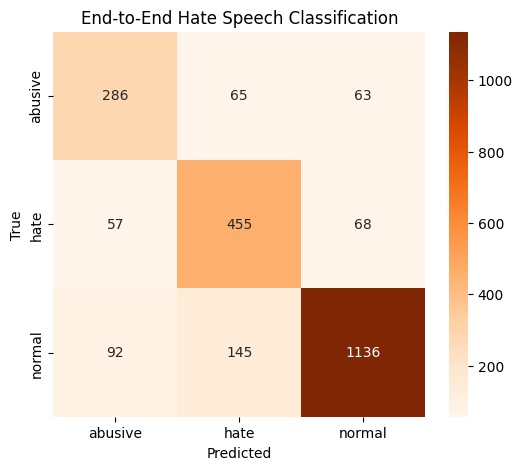


EGYPT DIALECT PERFORMANCE
Evaluated on 92 samples
              precision    recall  f1-score   support

     abusive       0.81      0.87      0.84        15
        hate       0.78      0.76      0.77        38
      normal       0.79      0.79      0.79        39

    accuracy                           0.79        92
   macro avg       0.80      0.81      0.80        92
weighted avg       0.79      0.79      0.79        92



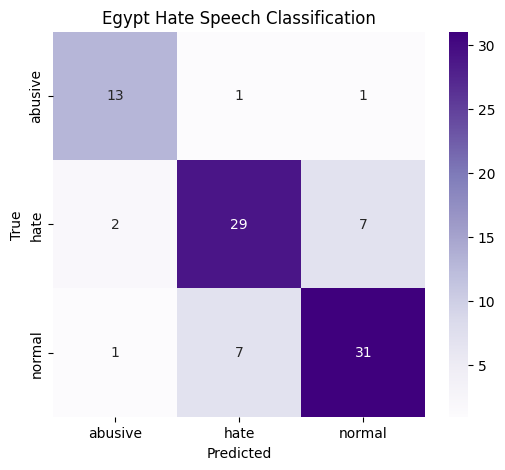


Ambiguous samples in Egypt (19):

Sample 1:
True: abusive, Predicted: hate
Text: انت قفاك وجعك للدرجة دي ومخليك بتهرتل ومش عارف بتقول ايه .. ع الاقل الاخوان كانت الدولة نفسها ضدهم بس انت اتظبطت بنيويورك

Sample 2:
True: normal, Predicted: abusive
Text: "شتمت وبعدين عملتلى بلوك عشان مشتمهاش حاجه اخر وساخه تربيه وسخه صحيح معلش يا دكتور متضايقش نفسك"

Sample 3:
True: hate, Predicted: normal
Text: ربنا ياخذه ويريح مصر فيه ...

SUDAN DIALECT PERFORMANCE
Evaluated on 665 samples
              precision    recall  f1-score   support

     abusive       0.44      0.53      0.48        89
        hate       0.66      0.63      0.64       106
      normal       0.89      0.86      0.87       470

    accuracy                           0.78       665
   macro avg       0.66      0.67      0.66       665
weighted avg       0.79      0.78      0.78       665



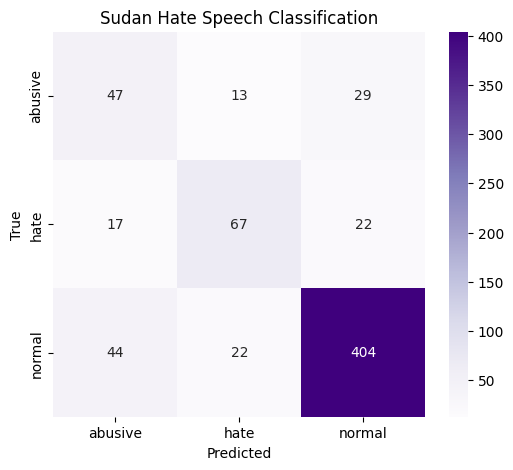


Ambiguous samples in Sudan (147):

Sample 1:
True: normal, Predicted: abusive
Text: عمسيب عليك دينك خلي الجنا ده في حالو

Sample 2:
True: abusive, Predicted: normal
Text: لو ما المدنيين في حكومه الجن دي صحو علي انو يجب ان يصطفو في صف الحقيقيه حايخسرو المد الشعبي دا والشعب ماعندو مايخسرو

Sample 3:
True: normal, Predicted: hate
Text: يعني تآكد الجغم

LEBANON DIALECT PERFORMANCE
Evaluated on 890 samples
              precision    recall  f1-score   support

     abusive       0.82      0.83      0.82       165
        hate       0.74      0.88      0.80       283
      normal       0.92      0.81      0.86       442

    accuracy                           0.83       890
   macro avg       0.83      0.84      0.83       890
weighted avg       0.84      0.83      0.84       890



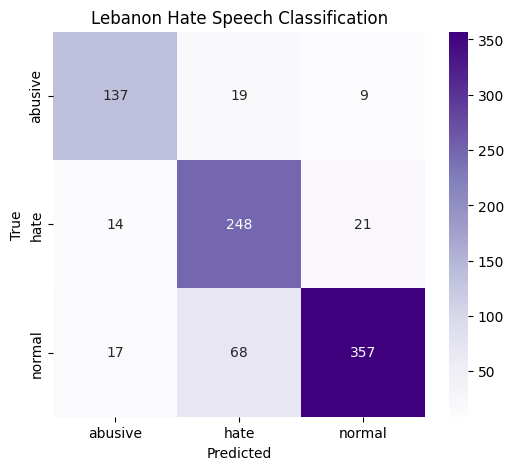


Ambiguous samples in Lebanon (148):

Sample 1:
True: abusive, Predicted: hate
Text: بايرن الكندرة

Sample 2:
True: hate, Predicted: normal
Text: العوني ما الو رب

Sample 3:
True: normal, Predicted: hate
Text: هامبورجر لحم خنزير  انت مش مسلم يا استاذ عمرو

TUNISIA DIALECT PERFORMANCE
Evaluated on 610 samples
              precision    recall  f1-score   support

     abusive       0.66      0.68      0.67       113
        hate       0.63      0.77      0.70       133
      normal       0.92      0.83      0.87       364

    accuracy                           0.79       610
   macro avg       0.74      0.76      0.75       610
weighted avg       0.81      0.79      0.80       610



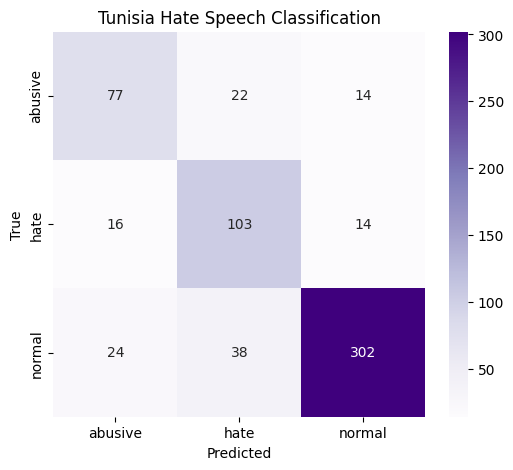


Ambiguous samples in Tunisia (128):

Sample 1:
True: normal, Predicted: abusive
Text: بالرغم إنو شمس الدين ميعجبنيش بالصح والله راجل لطفي زبي يضحك ابناس أكبر مضحكة تفو

Sample 2:
True: abusive, Predicted: normal
Text: فعلا عيب عرض شخص تافه

Sample 3:
True: abusive, Predicted: hate
Text: حمقى


In [ ]:
# Replace with your test data path
import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load test data
test_data = pd.read_csv("End-to-End_dataset_test.csv")
print(f"Loaded {len(test_data)} test samples")

# Filter to only supported dialects
SUPPORTED_DIALECTS = ["Egypt", "Sudan", "Lebanon", "Tunisia"]
test_data = test_data[test_data['dialect'].isin(SUPPORTED_DIALECTS)]
print(f"Filtered to {len(test_data)} supported dialect samples")

# Model Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def load_local_model(model_path):
    try:
        model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
        tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
        return model, tokenizer
    except Exception as e:
        print(f"❌ Error loading model from {model_path}: {str(e)}")
        try:
            !ls -l "{model_path}"
        except:
            pass
        raise

# Load models
try:
    dialect_model_path = "drive/MyDrive/dialect_stage1_marbert"
    dialect_model, dialect_tokenizer = load_local_model(dialect_model_path)
    dialect_model = dialect_model.to(device)
    print("✅ Successfully loaded dialect model")

    dialect_models = {
        "Egypt": "drive/MyDrive/Egyptian_marbert_model",
        "Sudan": "drive/MyDrive/Sudanese_marbert_model",
        "Lebanon": "drive/MyDrive/Lebanese_marbert_model",
        "Tunisia": "drive/MyDrive/Tunisian_marbert_model",
    }

    hs_models = {}
    for dialect, path in dialect_models.items():
        model, tokenizer = load_local_model(path)
        hs_models[dialect] = (model.to(device), tokenizer)
        print(f"✅ Loaded model for {dialect} dialect")

except Exception as e:
    print(f"❌ Critical error loading models: {str(e)}")
    raise

DIALECT_MAP = {0: "Egypt", 1: "Sudan", 2: "Lebanon", 3: "Tunisia"}
HS_MAP = {0: "abusive", 1: "hate", 2: "normal"}

# Evaluation Function
def evaluate_system(test_data):
    results = {dialect: {"true": [], "pred": [], "texts": []} for dialect in dialect_models.keys()}
    dialect_confusion = []

    for _, row in test_data.iterrows():
        text = row["commentaire"]
        true_dialect = row["dialect"]
        true_label = row["classe"]

        inputs = dialect_tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = dialect_model(**inputs).logits
        pred_idx = torch.argmax(outputs).item()
        pred_dialect = DIALECT_MAP.get(pred_idx, "Unknown")

        dialect_confusion.append((true_dialect, pred_dialect))

        if pred_dialect == true_dialect and pred_dialect in hs_models:
            model, tokenizer = hs_models[pred_dialect]
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
            with torch.no_grad():
                outputs = model(**inputs).logits
            pred_idx = torch.argmax(outputs).item()
            pred_label = HS_MAP.get(pred_idx, "Unknown")

            results[true_dialect]["true"].append(true_label)
            results[true_dialect]["pred"].append(pred_label)
            results[true_dialect]["texts"].append(text)

    return results, dialect_confusion

# Run Evaluation
print("\nStarting evaluation...")
results, dialect_confusion = evaluate_system(test_data)

# Generate Reports
print("\n" + "="*50)
print("DIALECT IDENTIFICATION PERFORMANCE")
print("="*50)

true_dialects, pred_dialects = zip(*dialect_confusion)
print(classification_report(true_dialects, pred_dialects, target_names=SUPPORTED_DIALECTS))

plt.figure(figsize=(8,6))
cm = confusion_matrix(true_dialects, pred_dialects, labels=SUPPORTED_DIALECTS)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SUPPORTED_DIALECTS, yticklabels=SUPPORTED_DIALECTS)
plt.title("Dialect Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Stage 2 Report (correct dialects only)
all_true_labels = []
all_pred_labels = []
for dialect in SUPPORTED_DIALECTS:
    all_true_labels.extend(results[dialect]["true"])
    all_pred_labels.extend(results[dialect]["pred"])

if all_true_labels:
    print("\n" + "="*50)
    print("HATE SPEECH CLASSIFICATION PERFORMANCE (Stage 2)")
    print(f"Evaluated on {len(all_true_labels)} samples (correct dialect only)")
    print("="*50)
    print(classification_report(all_true_labels, all_pred_labels, target_names=list(HS_MAP.values())))

    plt.figure(figsize=(6,5))
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=list(HS_MAP.values()))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=list(HS_MAP.values()),
                yticklabels=list(HS_MAP.values()))
    plt.title("Overall Hate Speech Classification (Stage 2)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
else:
    print("\n⚠️ No valid predictions for hate speech classification (Stage 2)")

# End-to-End Report (regardless of dialect accuracy)
end2end_true_labels = []
end2end_pred_labels = []

for _, row in test_data.iterrows():
    text = row["commentaire"]
    true_label = row["classe"]
    true_dialect = row["dialect"]

    inputs = dialect_tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        outputs = dialect_model(**inputs).logits
    pred_idx = torch.argmax(outputs).item()
    pred_dialect = DIALECT_MAP.get(pred_idx, "Unknown")

    if pred_dialect in hs_models:
        model, tokenizer = hs_models[pred_dialect]
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs).logits
        pred_idx = torch.argmax(outputs).item()
        pred_label = HS_MAP.get(pred_idx, "Unknown")

        end2end_true_labels.append(true_label)
        end2end_pred_labels.append(pred_label)

if end2end_true_labels:
    print("\n" + "="*50)
    print("END-TO-END SYSTEM PERFORMANCE (Stage 1 + 2 combined)")
    print(f"Evaluated on {len(end2end_true_labels)} samples (all, regardless of dialect accuracy)")
    print("="*50)
    print(classification_report(end2end_true_labels, end2end_pred_labels, target_names=list(HS_MAP.values())))

    plt.figure(figsize=(6,5))
    cm = confusion_matrix(end2end_true_labels, end2end_pred_labels, labels=list(HS_MAP.values()))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=list(HS_MAP.values()),
                yticklabels=list(HS_MAP.values()))
    plt.title("End-to-End Hate Speech Classification")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
else:
    print("\n⚠️ No valid End-to-End predictions")

# Per-Dialect Reports
for dialect in SUPPORTED_DIALECTS:
    data = results.get(dialect, {"true": [], "pred": []})
    if len(data["true"]) > 0:
        print("\n" + "="*50)
        print(f"{dialect.upper()} DIALECT PERFORMANCE")
        print(f"Evaluated on {len(data['true'])} samples")
        print("="*50)

        print(classification_report(data["true"], data["pred"], target_names=list(HS_MAP.values())))

        plt.figure(figsize=(6,5))
        cm = confusion_matrix(data["true"], data["pred"], labels=list(HS_MAP.values()))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                    xticklabels=list(HS_MAP.values()),
                    yticklabels=list(HS_MAP.values()))
        plt.title(f"{dialect} Hate Speech Classification")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        ambiguous = []
        for text, true, pred in zip(data["texts"], data["true"], data["pred"]):
            if true != pred:
                ambiguous.append({"text": text, "true": true, "pred": pred})

        print(f"\nAmbiguous samples in {dialect} ({len(ambiguous)}):")
        for i, sample in enumerate(ambiguous[:3], 1):
            print(f"\nSample {i}:")
            print(f"True: {sample['true']}, Predicted: {sample['pred']}")
            print(f"Text: {sample['text'][:200]}{'...' if len(sample['text']) > 200 else ''}")
    else:
        print(f"\n⚠️ No samples for {dialect} dialect")
